<a href="https://colab.research.google.com/github/Bienbaz/Simple-Linear-Regression-Marketing-ROI-Analysis/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression – Marketing ROI Analysis

Upload `marketing_and_sales_data_evaluate_lr.csv` when prompted and run all cells.

In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Set plot style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Load the dataset
# Ensure 'marketing_and_sales_data_evaluate_lr.csv' is uploaded to your Colab environment
file_path = 'marketing_and_sales_data_evaluate_lr.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Check dataset info
print("\n--- Dataset Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Drop missing values to maintain data integrity for regression
df = df.dropna()
print(f"\nDataset shape after dropping missing values: {df.shape}")

--- First 5 Rows ---


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB

--- Missing Values ---
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Dataset shape after dropping missing values: (4546, 4)


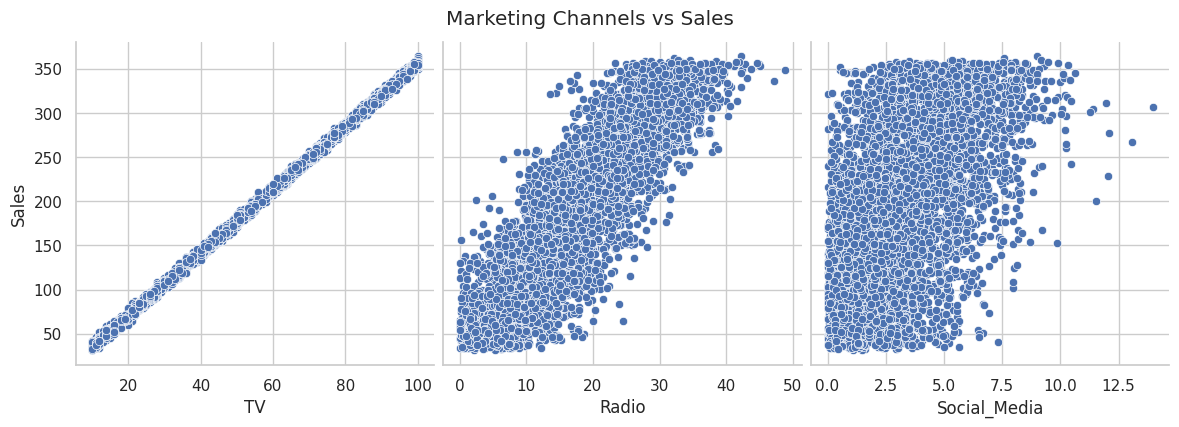


--- Correlation with Sales ---
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


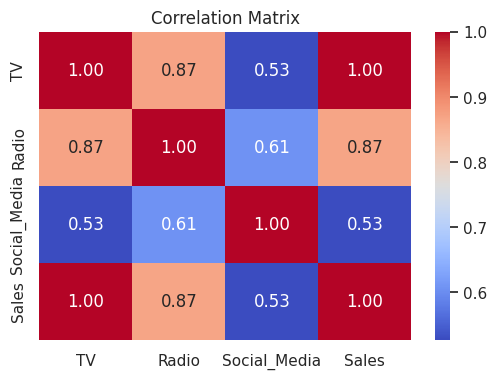

In [36]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Social_Media'], y_vars=['Sales'], height=4, aspect=1, kind='scatter')
plt.suptitle('Marketing Channels vs Sales', y=1.05)
plt.show()

# Calculate correlation matrix
correlation_matrix = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()
print("\n--- Correlation with Sales ---")
print(correlation_matrix['Sales'].sort_values(ascending=False))

# Heatmap of correlations
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Data Cleaning

In [37]:
# Automatically select the best predictor based on correlation
correlations = correlation_matrix['Sales'].drop('Sales')
best_predictor = correlations.idxmax()

print(f"The independent variable most correlated with Sales is: {best_predictor}")

# Define independent variable (X) and dependent variable (y)
X = df[best_predictor]
y = df['Sales']

# Add a constant to the independent variable (required for statsmodels OLS)
X_const = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_const).fit()

# Print the summary
print("\n--- OLS Regression Results ---")
print(model.summary())

The independent variable most correlated with Sales is: TV

--- OLS Regression Results ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:39:38   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

## Exploratory Data Analysis

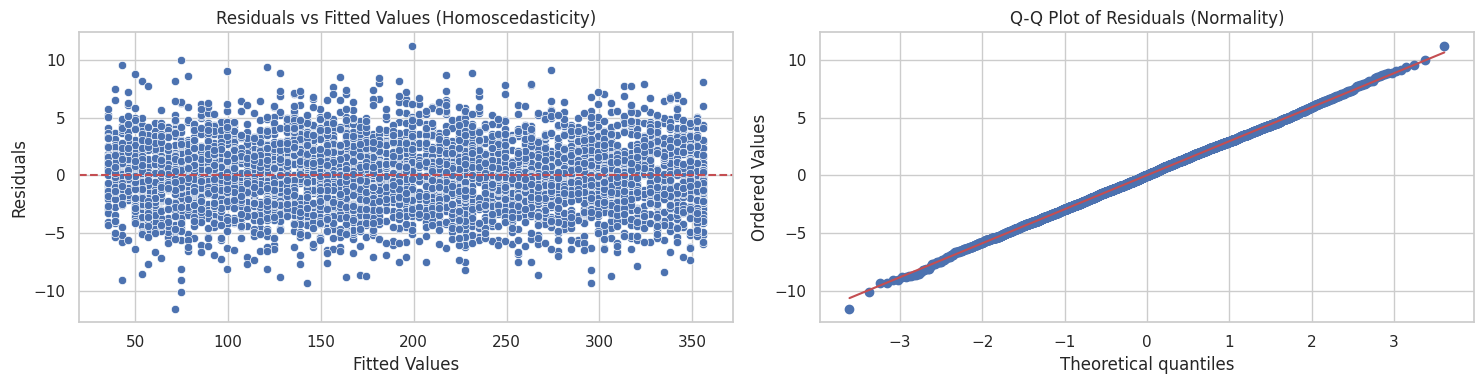

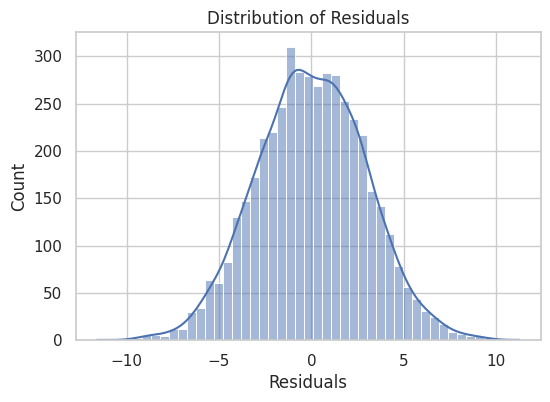

In [38]:
# Get fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(15, 4))

# 1. Linearity & Homoscedasticity: Residuals vs Fitted Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Homoscedasticity)')

# 2. Normality: Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals (Normality)')

plt.tight_layout()
plt.show()

# 3. Normality: Histogram of Residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()